# Inter-annual

In [42]:
import os.path

import pandas as pd
import numpy as np

import rasterio
from matplotlib import pyplot as plt

In [34]:
COMPOSITES_NO_NAN_LOG_PATH_tif = "/home/martin/repositories/RemoteSensing/Download/ndvi_NAN_fill/inventory_tif"
COMPOSITES_NO_NAN_LOG_PATH = "/home/martin/repositories/RemoteSensing/Download/ndvi_NAN_fill/inventory_np"

THRESHOLD = 0.15

In [13]:
inventory_tif = pd.read_csv(COMPOSITES_NO_NAN_LOG_PATH_tif, index_col=0, header = 0)
inventory_tif = inventory_tif.set_index(["year", "month"])
inventory_tif.sort_index(inplace=True)



inventory = pd.read_csv(COMPOSITES_NO_NAN_LOG_PATH, index_col=0, header = 0)

min_year = inventory.year.min()
max_year = inventory.year.max()

months = [7,10]

inventory = inventory.set_index(["year", "month"])
inventory.sort_index(inplace=True)

## Vizualization

In [4]:
print(inventory)

                                                         path
year month                                                   
2015 1      /home/martin/repositories/RemoteSensing/Downlo...
     4      /home/martin/repositories/RemoteSensing/Downlo...
     7      /home/martin/repositories/RemoteSensing/Downlo...
     10     /home/martin/repositories/RemoteSensing/Downlo...
2016 1      /home/martin/repositories/RemoteSensing/Downlo...
     4      /home/martin/repositories/RemoteSensing/Downlo...
     7      /home/martin/repositories/RemoteSensing/Downlo...
     10     /home/martin/repositories/RemoteSensing/Downlo...
2017 1      /home/martin/repositories/RemoteSensing/Downlo...
     4      /home/martin/repositories/RemoteSensing/Downlo...
     7      /home/martin/repositories/RemoteSensing/Downlo...
     10     /home/martin/repositories/RemoteSensing/Downlo...
2018 1      /home/martin/repositories/RemoteSensing/Downlo...
     4      /home/martin/repositories/RemoteSensing/Downlo...
     7  

Rozmery (Šírka x Výška): 2500 x 2500
Počet kanálov (Bands): 1
Tvar NumPy poľa: (2500, 2500)
Dátový typ pixelov: float32


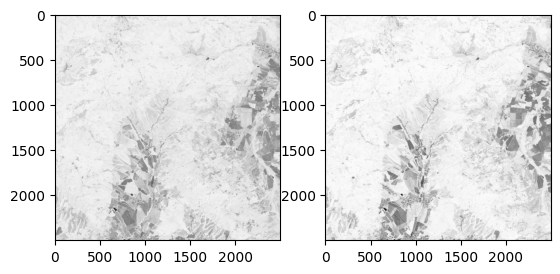

In [5]:
path_start = inventory_tif.loc[(2018, 7)]["path"]
sample_start_rast = rasterio.open(path_start)
sample_start = sample_start_rast.read()
sample_start = sample_start.squeeze() # (1, 2500, 2500) -> (2500, 2500)

path_end = inventory_tif.loc[(2023,7)]["path"]
sample_end_rast = rasterio.open(path_end)
sample_end = sample_end_rast.read()
sample_end = sample_end.squeeze()

print(f"Rozmery (Šírka x Výška): {sample_end_rast.width} x {sample_end_rast.height}")
print(f"Počet kanálov (Bands): {sample_end_rast.count}")
print(f"Tvar NumPy poľa: {sample_end.shape}")
print(f"Dátový typ pixelov: {sample_end.dtype}")


fig, (ax1, ax2) = plt.subplots(1, 2)

ax1.imshow(sample_start, cmap=plt.get_cmap("gray"))
ax2.imshow(sample_end, cmap=plt.get_cmap("gray"))

plt.show()


(2015, 1)
    NaN: 0
    min: -0.6000000238418579, max: 1.0
(2015, 4)
    NaN: 0
    min: -0.6000000238418579, max: 1.0
(2015, 7)
    NaN: 0
    min: -0.6000000238418579, max: 1.0
(2015, 10)
    NaN: 0
    min: -0.8518518805503845, max: 1.0
(2016, 1)
    NaN: 0
    min: -0.7749999761581421, max: 1.0
(2016, 4)
    NaN: 0
    min: -1.0, max: 1.0
(2016, 7)
    NaN: 0
    min: -0.3360995948314667, max: 0.96809983253479
(2016, 10)
    NaN: 0
    min: -0.7178683280944824, max: 1.0
(2017, 1)
    NaN: 0
    min: -0.5824176073074341, max: 1.0
(2017, 4)
    NaN: 0
    min: -1.0, max: 0.9743636250495911
(2017, 7)
    NaN: 0
    min: -0.7063491940498352, max: 0.9693877696990967
(2017, 10)
    NaN: 0
    min: -0.5411764979362488, max: 1.0
(2018, 1)
    NaN: 0
    min: -0.3497822880744934, max: 1.0
(2018, 4)
    NaN: 0
    min: -0.48736461997032166, max: 0.9474100470542908
(2018, 7)
    NaN: 0
    min: -0.625668466091156, max: 0.9914953708648682
(2018, 10)
    NaN: 0
    min: -0.4864864945411682, ma

(array([ 1.,  0.,  2.,  6.,  4.,  3.,  6.,  2.,  5., 15.]),
 array([0.21658987, 0.28035635, 0.34412283, 0.40788928, 0.47165576,
        0.53542221, 0.59918869, 0.66295516, 0.72672164, 0.79048812,
        0.8542546 ]),
 <BarContainer object of 10 artists>)

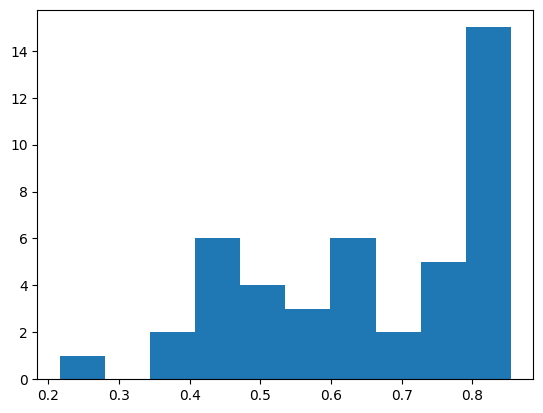

In [10]:
sampleX = 0
sampleY = 0

values = []

for index, record in inventory_tif.iterrows():
    path = record["path"]
    #print(path)
    with rasterio.open(path) as src:
        arr = src.read().squeeze()
        values.append(arr[sampleX, sampleY])
        
        print(index)
        nans = (np.isnan(arr)).sum()
        print(f"    NaN: {nans}")
        if nans == arr.shape[0]*arr.shape[1]:
            print("    !! ALL NAN !!")
        else:
            print(f"    min: {np.nanmin(arr)}, max: {np.nanmax(arr)}")
    
plt.hist(values)

## Backward Differences

In [14]:
# Loads observation into matrix [year, month]
composite_matrix = [] # [year, month]

for year in range(min_year,max_year+1):
    composite_matrix.append([])
    for month in months:
        new_composit = np.load(inventory.loc[(year,month)]["path"])
        composite_matrix[-1].append(new_composit)


In [15]:
composite_matrix = np.array(composite_matrix)
print(composite_matrix.shape)

(11, 2, 2500, 2500)


for generic month $ m' $ and subset of composites $ \textbf{X}_m' =  \left\{ X_{y, m = m'} \right\}; y \in \left\{ min\_year, ..., max\_year \right\} $ 

$ X^{BD}_{y,m'} = X_{y,m'}-X_{y-1, m'} $

In [16]:
X_BD = np.empty(composite_matrix.shape) #Back diference
X_BD[:] = np.nan


for i in range(1, composite_matrix.shape[0]):
    X_BD[i,:] = composite_matrix[i,:] - composite_matrix[i-1,:]

In [17]:
# check of BD computation
for m in range(0, composite_matrix.shape[1]):
    for yr in  range(1, composite_matrix.shape[0]):
        for x in range(1, composite_matrix.shape[2]):
            for y in range(1, composite_matrix.shape[3]):
                expected = composite_matrix[yr,m,x,y] - composite_matrix[yr-1,m,x,y]
                calculated = X_BD[yr,m,x,y]
                
                if expected != calculated:
                    raise Exception (f"Value {calculated} does not match expected {expected} at {yr},{m},{x},{y}")

### Visualize

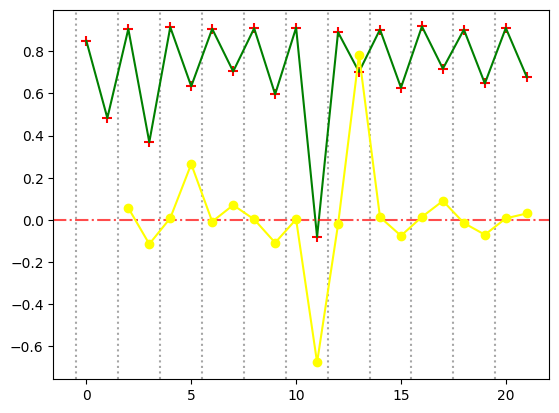

In [18]:
#OBSERVED_POINT = [21,40]
#OBSERVED_POINT = [40,80]
#OBSERVED_POINT = [40,99]
OBSERVED_POINT = [250,600]
OBSERVED_POINT = [0,330]
OBSERVED_POINT = [0,440]
FAKE_ZERO_LINE = 0

time_serie_one_point = []
time_serie_bd = []
counter = -0.5
for y in range(composite_matrix.shape[0]):
    plt.axvline(x=counter, color='gray', linestyle=':', alpha=0.7)
    for m in range(composite_matrix.shape[1]):
        time_serie_one_point.append(composite_matrix[y,m,OBSERVED_POINT[0],OBSERVED_POINT[1]])
        time_serie_bd.append(X_BD[y,m,OBSERVED_POINT[0],OBSERVED_POINT[1]]+FAKE_ZERO_LINE)
        counter += 1
        

plt.plot(time_serie_one_point, color='green')
plt.scatter(y=time_serie_one_point, x=range(len(time_serie_one_point)), color='red', marker='+', alpha=1, s=50)

plt.axhline(y = FAKE_ZERO_LINE, color='red', linestyle='-.', alpha=0.7)
plt.plot(time_serie_bd, color='yellow', marker='o')

plt.show()

ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (3,) and arg 1 with shape (11,).

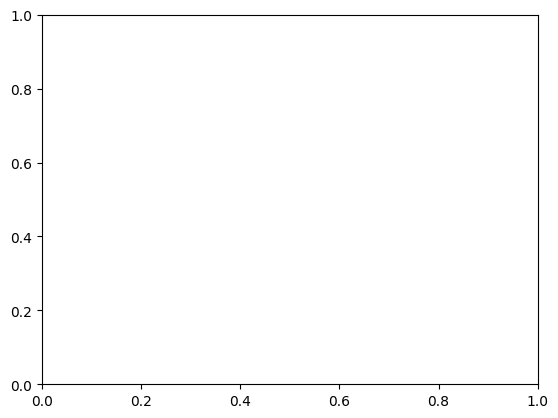

In [22]:
month = 0
width = 0.2

x_NDVI = [x - width for x in range(composite_matrix.shape[1]+1)]
x_X_BD = [x for x in range(composite_matrix.shape[1]+1)]
x=["2015","2016","2017","2018", "2019", "2020", "2021", "2022", "2023","2024","2025"]


off_set = np.min(composite_matrix[:,month, OBSERVED_POINT[0], OBSERVED_POINT[1]])-10
plt.bar(x_NDVI, composite_matrix[:,month, OBSERVED_POINT[0], OBSERVED_POINT[1]]-off_set, width=width, color = 'green', label=f"NDVI (decreased by {off_set})")
plt.bar(x_X_BD, X_BD[:,month, OBSERVED_POINT[0], OBSERVED_POINT[1]], width=width, color = 'orange', label="X_BD")


y_f =  np.argmax(X_BD[:,month,OBSERVED_POINT[0],OBSERVED_POINT[1]] < 0)
print(X_BD[:,month,OBSERVED_POINT[0],OBSERVED_POINT[1]])
if (y_f > 0):
    v_X_RD = [ composite_matrix[y,month,OBSERVED_POINT[0],OBSERVED_POINT[1]] - composite_matrix[y_f-1,month,OBSERVED_POINT[0],OBSERVED_POINT[1]] for y in range(y_f, composite_matrix.shape[0])  ]
    
    x_X_RD = [x + width for x in range(y_f, composite_matrix.shape[1]+1)]
    plt.bar(x_X_RD, v_X_RD, width=width, color = 'cyan', label="X_RD")

plt.legend()

We then identify the first year that exhibits a negative variation in the spectral index, compared to the previous year, with an absolute value greater than a threshold $ y_f $

In [35]:
# We then identify the first year that exhibits a negative variation in the spectral index, compared to the previous year, with an absolute value greater than a threshold 
negative_mask = X_BD < 0
sus_mask = np.logical_and( np.absolute(X_BD) >= THRESHOLD, negative_mask )

print(np.sum(negative_mask), "of neg")
print(np.sum(sus_mask), "of sus")

59224089 of neg
12311357 of sus


Year $ y_f $ is the last one before the vegetation index drops and $ X_{y_f-1, m'} $ can be considered as a reference value in pre-disturbance conditions.

This value is used to compute $ X^{RD}_{y,m'} = X_{y,m'} - X_{y_f-1,m'} ; y \in \{ y_f,... \} $

We consider as disturbed areas only the pixels that show a negative variation of the index from the reference year for at least three years.

Given the first year of detection $ y_d $, the pixel is considered as disturbed if $ X^{RD}_{y,m'} \le TH \quad \forall\   y \in \{ y_d,...,y_d+3 \} $.

If the number of years available in the time series after the first detection is less than three, or zero in the case of near real-time detection, the condition is still considered fulfilled




In [36]:
def check_disturbance_condition(X_RD) -> bool:
    years_negative_trend_from_reference_year = np.logical_and( X_RD < 0, np.absolute(X_RD) >= THRESHOLD)
    
    countOfContinuousDisturbances = 0
    for x_rd in years_negative_trend_from_reference_year:
        if x_rd:
            countOfContinuousDisturbances += 1
        else:
            break
        
    return countOfContinuousDisturbances >= 4 or countOfContinuousDisturbances == len(X_RD)

In [38]:
M = []
for month in range(composite_matrix.shape[1]):
    sus_mask_month = sus_mask[:,month, :, :] # shape = [6, 100, 100] => 6-year , 100-pix_w, 100-pix_h
    #print(sus_mask_month.shape)
    
    m = np.zeros(sus_mask_month.shape[1:])
    for x in range(sus_mask_month.shape[-2]):
        for y in range(sus_mask_month.shape[-1]):
            sus_mask_month_point = sus_mask_month[:,x,y] # one point in month month over more years
            
            y_d = -1
            
            y_f_potentionals = np.where(sus_mask_month_point == True)
            if len(y_f_potentionals[0]) > 0:
                #print(y_f_potentionals)
                y_f = y_f_potentionals[0][0]
                X_y_f_m1 = composite_matrix[y_f-1, month, x, y] # reference value form prev year
                X_RD = np.array([ X_y - X_y_f_m1 for X_y in composite_matrix[y_f : ,month, x, y] ])
                
                condition_met = check_disturbance_condition(X_RD)
                if(check_disturbance_condition(X_RD)):
                    y_d = y_f
            
            m[x,y] = y_d
            
    M.append(m)     
        
M = np.array(M)    
print((sus_mask_month.shape()))
print(np.sum( M > -1 ))
    

NameError: name 'shape' is not defined

# Intra-annual

|  Level  |                           Rule                           |
|:-------:|:--------------------------------------------------------:|
|   Low   |                  Detected for one month                  |
| Medium  |         Detected for two months in the same year         |
|  High   | Detected for more than two months or two different years |

In [39]:
disturbance_years = np.zeros(composite_matrix.shape[-2:])

disturbance_reliability = np.zeros(disturbance_years.shape)
disturbance_reliability[:] = np.nan

from enum import Enum
class Detection_Reliability_Metric(Enum):
    Low = 1     # Detected for one month 
    Medium = 2  # Detected for two months in the same year
    High = 3    # Detected for more than two months or two different years
    Ambiguous = 0 # Cannot be clearly identified (f.e. it is last in time series)
    
def categorize_slic_through_months(slice) -> Detection_Reliability_Metric:
    month_of_detection = np.nanargmin(slice)
    
    if month_of_detection + 1 >= len(slice):
        return Detection_Reliability_Metric.Ambiguous
    
    months_after_detection = slice[month_of_detection : ] 
    
    found_in_months =  np.sum( np.logical_not(np.isnan(months_after_detection)) )
    found_in_years = len(np.unique(months_after_detection)) # nan is also unique value
    
    if (found_in_months > 2 or found_in_years > 3):
        return Detection_Reliability_Metric.High
    elif (found_in_months == 2 and found_in_years <= 2):
        return Detection_Reliability_Metric.Medium
    elif (found_in_months < 2):
        return Detection_Reliability_Metric.Low
    
    return Detection_Reliability_Metric.Ambiguous # Fallback
    

In [40]:
M[M==-1] = np.nan
disturbance_years = np.nanmin(M, axis=0) # ! step not in instruction !


for x in range(disturbance_years.shape[0]):
    for y in range(disturbance_years.shape[1]):
        if( np.isnan( disturbance_years[x,y] ) ): # if is nan continue
            continue

        point_throw_months = M[:,x,y]
        disturbance_reliability[x,y] = categorize_slic_through_months(point_throw_months).value   
        


/tmp/ipykernel_19016/1959146944.py:2: RuntimeWarning: All-NaN slice encountered
  disturbance_years = np.nanmin(M, axis=0) # ! step not in instruction !


In [43]:
# Reference metadata
PATH_TO_METADATA_SAMPLE = "/home/martin/repositories/RemoteSensing/Download/ndvi_NAN_fill/2018_4.tif"
PATH_TO_OUT = "/home/martin/repositories/RemoteSensing/"

with rasterio.open(PATH_TO_METADATA_SAMPLE, 'r') as gtif:
    gtif_profile = gtif.profile

disturbance_years_mapped = np.array(disturbance_years)
disturbance_years_mapped[ np.logical_not(np.isnan(disturbance_years)) ] += min_year

with rasterio.open(os.path.join(PATH_TO_OUT, "DONE_Disturbance.tif"), 'w', **gtif_profile) as gtif:
    gtif.write(disturbance_years_mapped, 1)
with rasterio.open(os.path.join(PATH_TO_OUT, "DONE_Reliability.tif"), 'w', **gtif_profile) as gtif:
    gtif.write(disturbance_reliability, 1)

print("--------------------------------")


--------------------------------
